<a href="https://www.kaggle.com/code/lalit7881/goldprice-analysis-2020-26-eda?scriptVersionId=340265389" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shakhnoza12/gold-price-analysis-20002026/gold_stock.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shakhnoza12/gold-price-analysis-20002026/gold_stock.csv")

In [3]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,GOLD,GOLD,GOLD,GOLD,GOLD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2014-03-17,4.711997032165527,4.85016815549002,4.425025639793251,4.425025639793251,68200
3,2014-03-18,5.048568248748779,5.278853682840762,4.694282757608514,4.711997099740122,135600
4,2014-03-19,4.959996223449707,5.1017102661133835,4.90685354191906,5.013138904980353,25600


In [4]:
df.tail()

,Price,Close,High,Low,Open,Volume
2965,2025-12-24,34.49665069580078,34.86352978677981,33.118371818243254,33.56457438016267,632900
2966,2025-12-26,34.298336029052734,35.40889108972075,33.475332803245784,35.20066272507017,519400
2967,2025-12-29,33.13819885253906,33.765864568292805,32.483764161201734,33.46541808947349,543700
2968,2025-12-30,33.167945861816406,33.60423436098219,32.860558461759986,33.48524727621538,478900
2969,2025-12-31,33.76288604736328,34.07027345633446,33.26710210016989,33.85212730915934,401800


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2970 non-null   object
 1   Close   2969 non-null   object
 2   High    2969 non-null   object
 3   Low     2969 non-null   object
 4   Open    2969 non-null   object
 5   Volume  2969 non-null   object
dtypes: object(6)
memory usage: 139.3+ KB


In [6]:
df.describe()

,Price,Close,High,Low,Open,Volume
count,2970,2969,2969,2969,2969,2969
unique,2970,2468,2918,2939,2951,1496
top,2025-12-31,3.75582218170166,3.7915920532161964,4.60762882232666,3.6494407653808594,4200
freq,1,9,3,3,2,18


In [7]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Price     object
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object

In [10]:
df.shape

(2970, 6)

In [11]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df.nunique()

Price     2970
Close     2468
High      2918
Low       2939
Open      2951
Volume    1496
dtype: int64

## EDA

First 5 Rows
        Price              Close                High                Low  \
0      Ticker               GOLD                GOLD               GOLD   
1        Date                NaN                 NaN                NaN   
2  2014-03-17  4.711997032165527    4.85016815549002  4.425025639793251   
3  2014-03-18  5.048568248748779   5.278853682840762  4.694282757608514   
4  2014-03-19  4.959996223449707  5.1017102661133835   4.90685354191906   

                Open  Volume  
0               GOLD    GOLD  
1                NaN     NaN  
2  4.425025639793251   68200  
3  4.711997099740122  135600  
4  5.013138904980353   25600  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2970 non-null   object
 1   Close   2969 non-null   object
 2   High    2969 non-null   object
 3   Low     2969 non-null   object
 4   Open    2969 non-null  

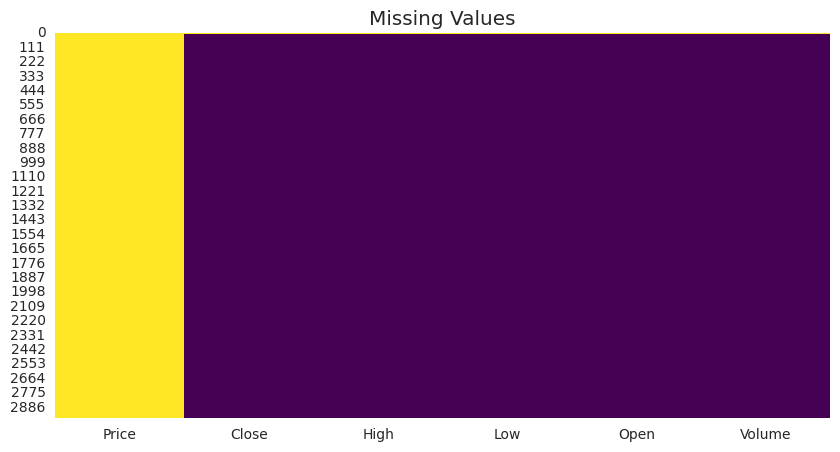

Price     float64
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object
       Price        Close         High          Low         Open        Volume
count    0.0  2970.000000  2970.000000  2970.000000  2970.000000  2.970000e+03
mean     NaN    14.737870    15.037816    14.440203    14.748615  1.355350e+05
std      NaN    11.667536    11.899621    11.433692    11.675293  1.787096e+05
min      NaN     2.952644     3.019972     2.809714     2.971826  0.000000e+00
25%      NaN     4.830487     4.920759     4.743694     4.829547  1.825000e+04
50%      NaN     6.962566     7.068493     6.799799     6.924395  7.280000e+04
75%      NaN    26.288105    26.760580    25.782526    26.337991  1.904000e+05
max      NaN    44.811447    45.260331    44.085603    44.811451  2.739600e+06


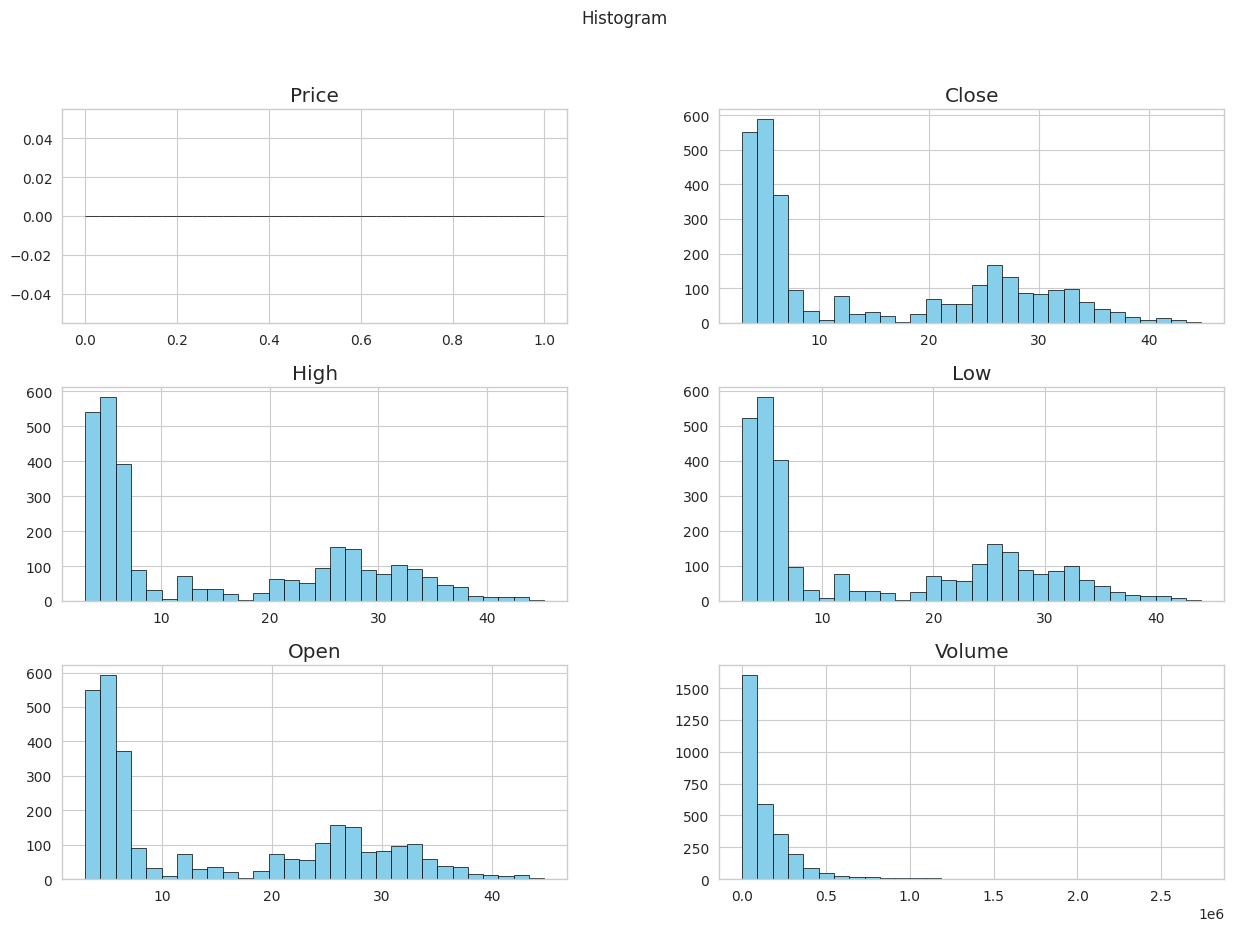

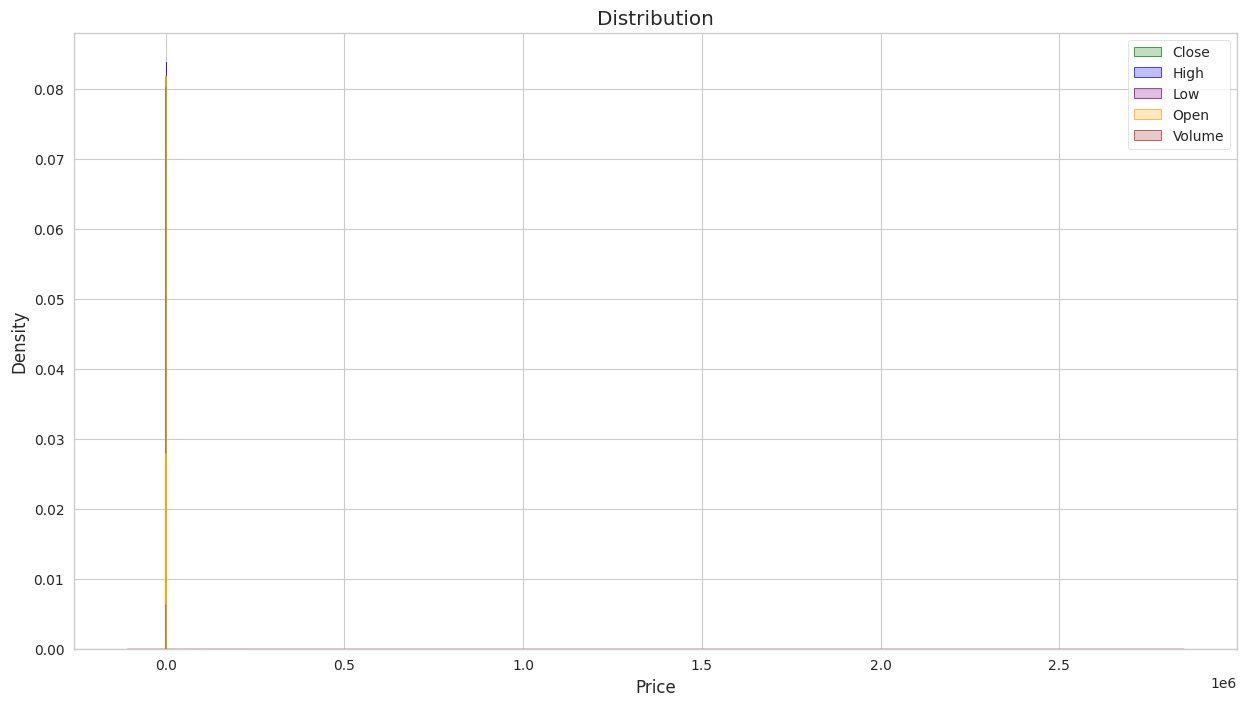

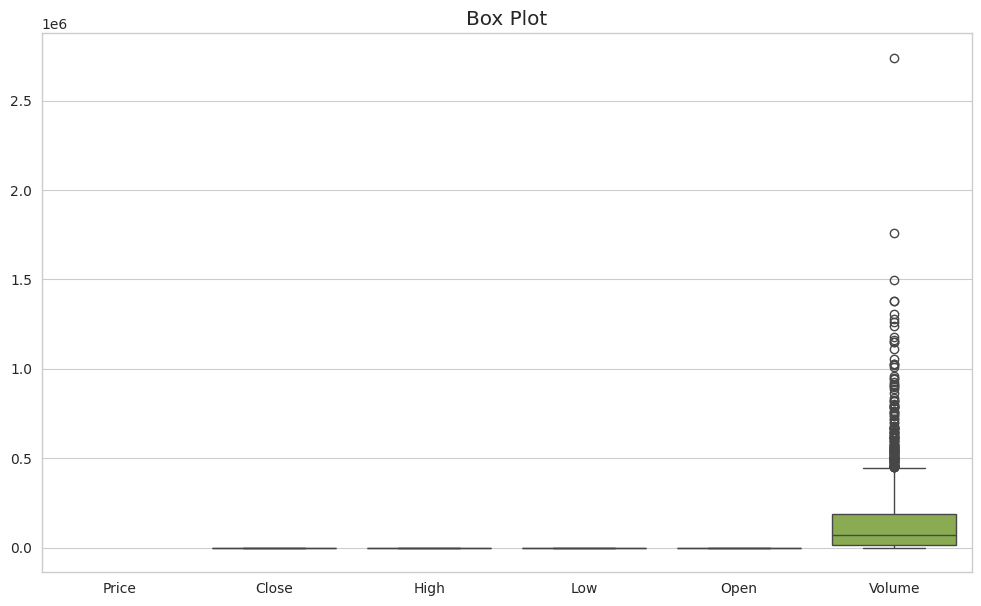

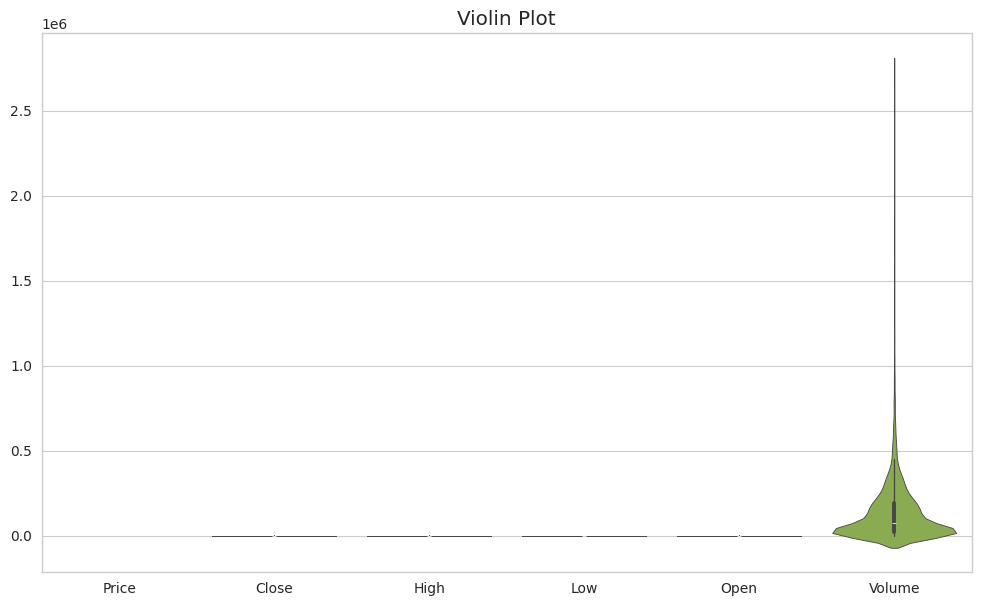

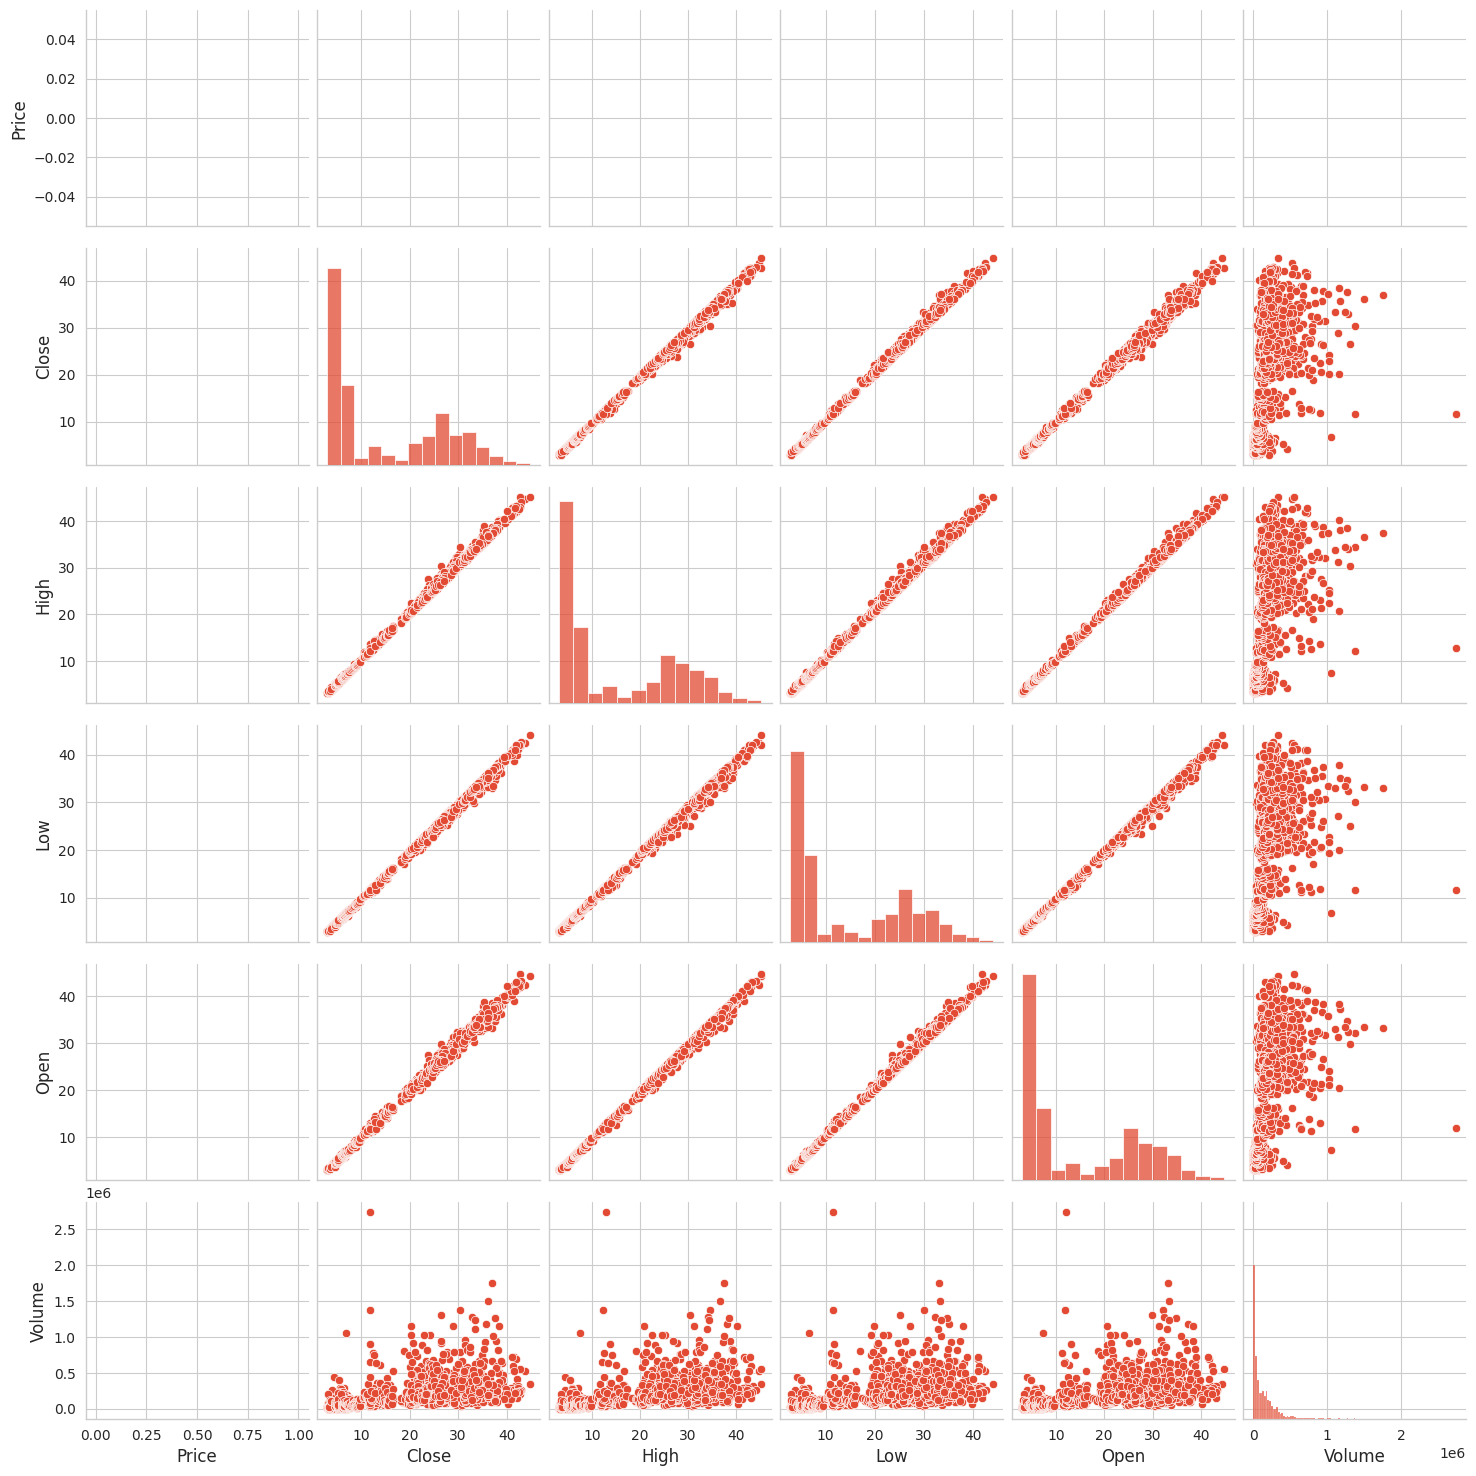

        Price     Close      High       Low      Open    Volume
Price     NaN       NaN       NaN       NaN       NaN       NaN
Close     NaN  1.000000  0.999584  0.999589  0.999112  0.626344
High      NaN  0.999584  1.000000  0.999430  0.999572  0.633233
Low       NaN  0.999589  0.999430  1.000000  0.999503  0.619351
Open      NaN  0.999112  0.999572  0.999503  1.000000  0.625494
Volume    NaN  0.626344  0.633233  0.619351  0.625494  1.000000


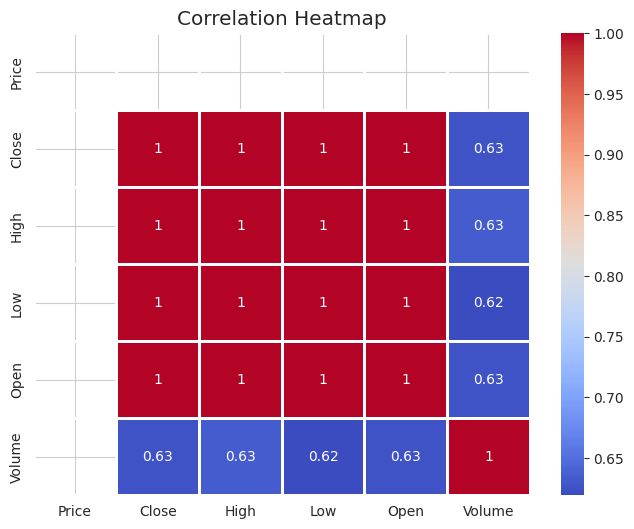

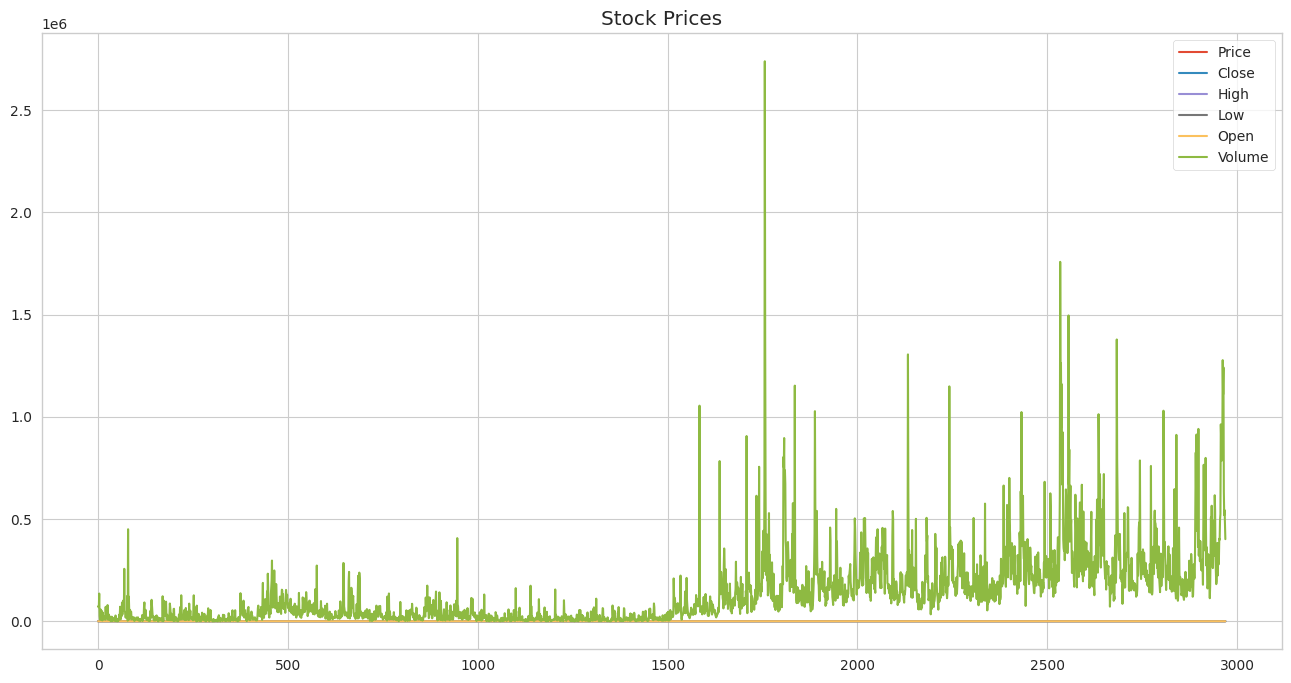

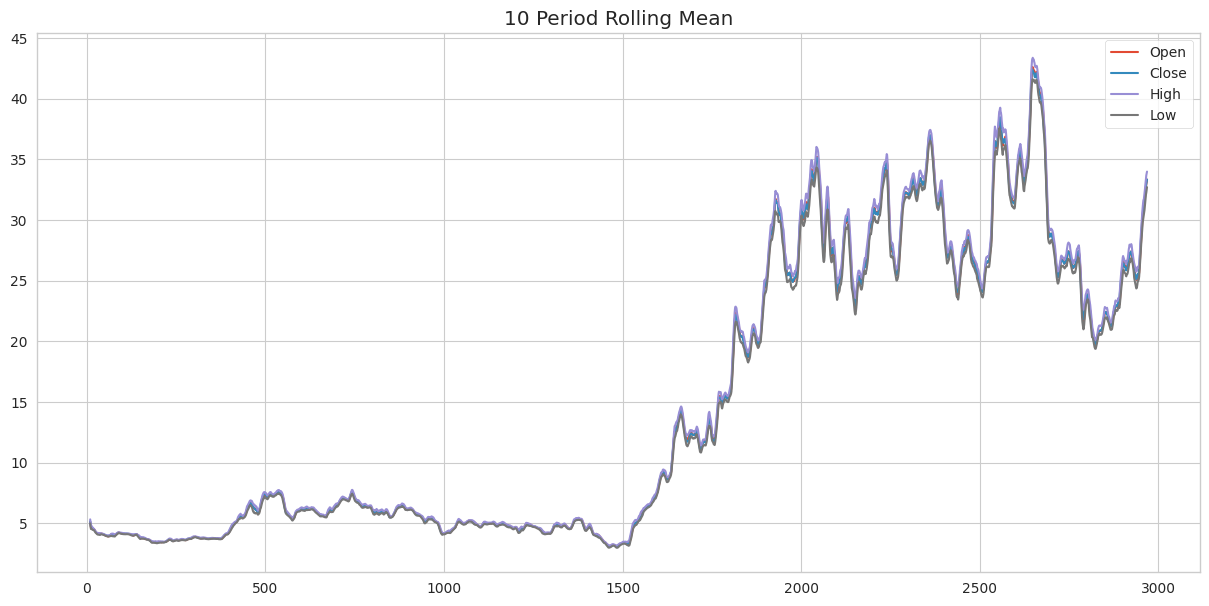

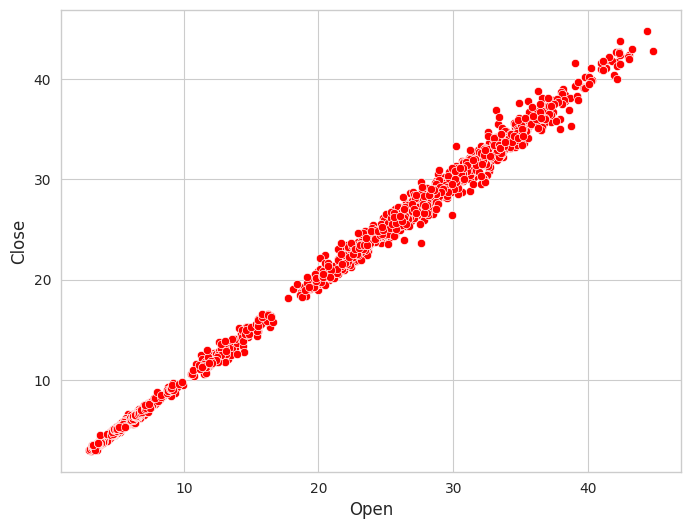

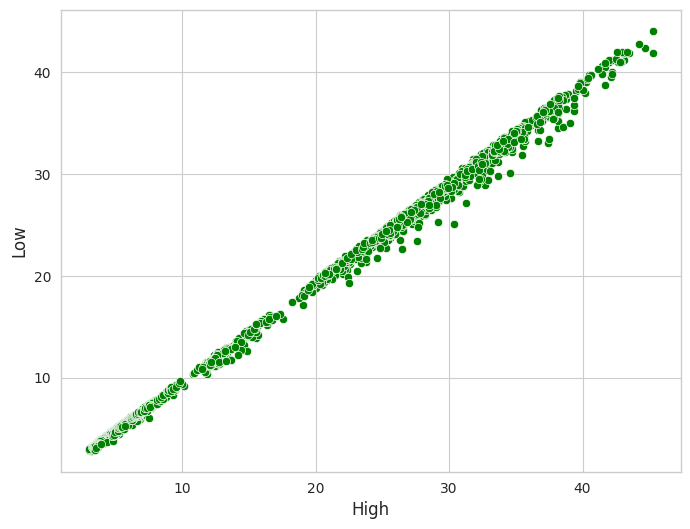

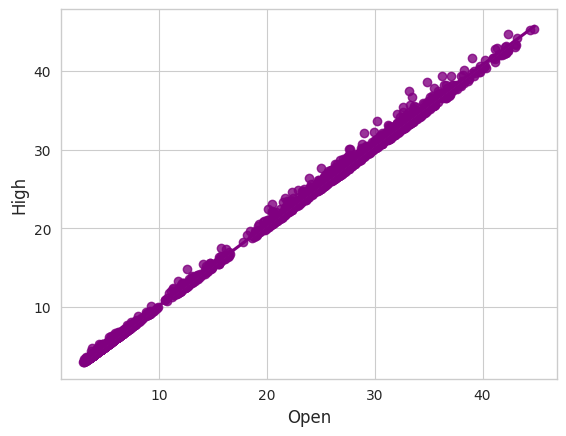

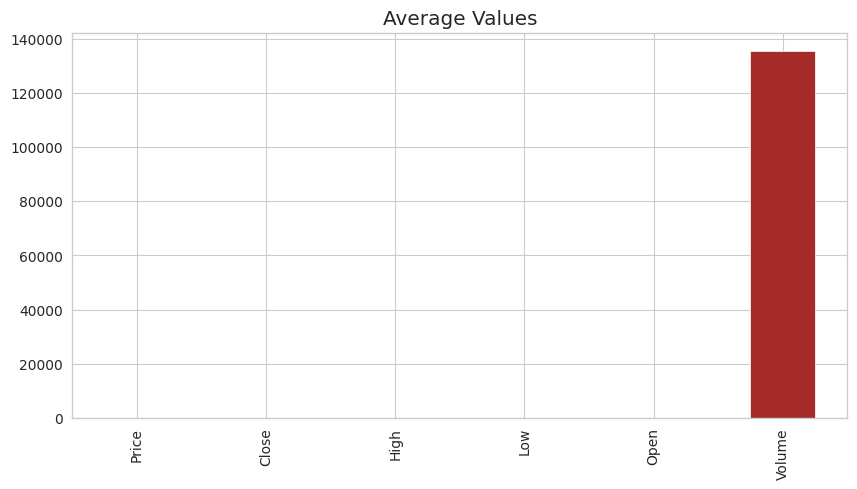

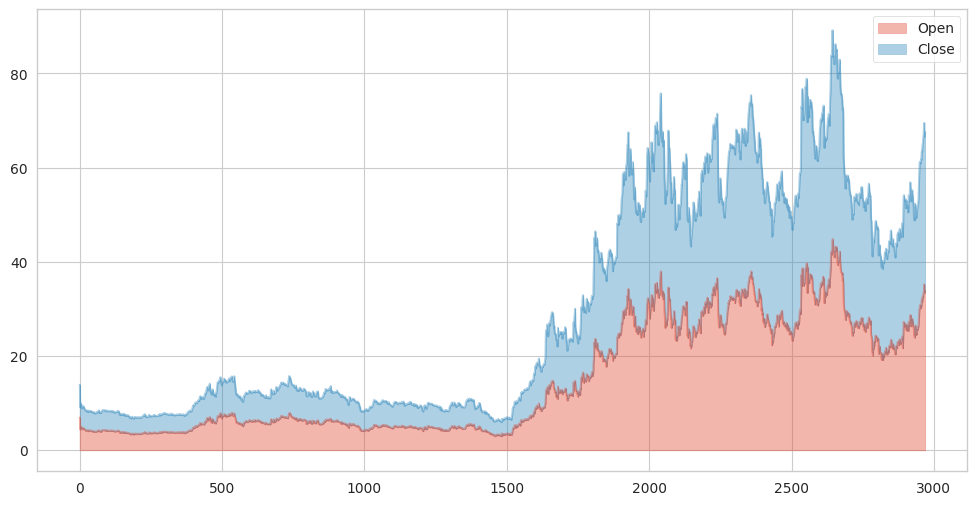

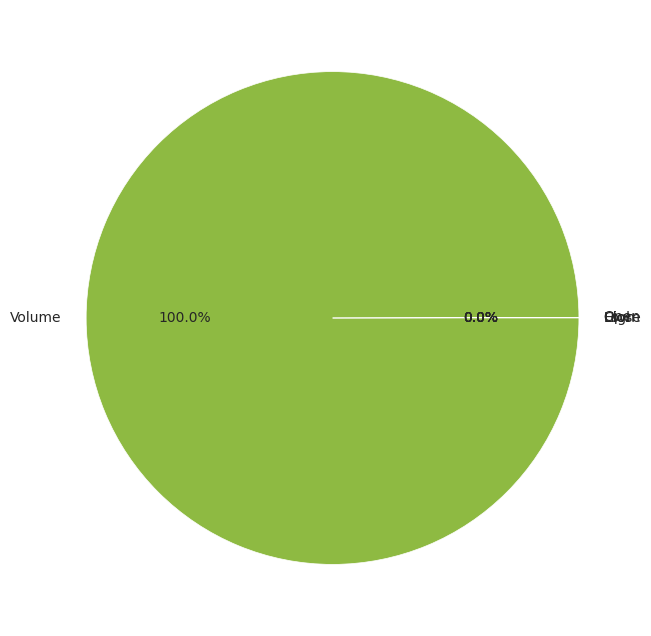

EDA COMPLETED SUCCESSFULLY


In [13]:
import plotly.express as px

plt.style.use("ggplot")
sns.set_style("whitegrid")

# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("="*60)
print("First 5 Rows")
print(df.head())

print("="*60)
print(df.info())

print("="*60)
print(df.describe(include="all"))

# ==========================================================
# COLUMN NAMES
# ==========================================================

print(df.columns)

# ==========================================================
# CLEAN NUMERIC COLUMNS
# ==========================================================

numeric_cols = ['Price','Close','High','Low','Open','Volume']

for col in numeric_cols:

    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================================
# MISSING VALUES
# ==========================================================

print(df.isnull().sum())

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Values")
plt.show()

# Fill Missing Values

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# ==========================================================
# DATA TYPES
# ==========================================================

print(df.dtypes)

# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

print(df[numeric_cols].describe())

# ==========================================================
# HISTOGRAM
# ==========================================================

df[numeric_cols].hist(
    figsize=(15,10),
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Histogram")
plt.show()

# ==========================================================
# KDE PLOT
# ==========================================================

plt.figure(figsize=(15,8))

colors=["red","green","blue","purple","orange","brown"]

for c,col in zip(colors,numeric_cols):

    sns.kdeplot(
        df[col],
        fill=True,
        color=c,
        label=col
    )

plt.legend()
plt.title("Distribution")
plt.show()

# ==========================================================
# BOXPLOT
# ==========================================================

plt.figure(figsize=(12,7))

sns.boxplot(data=df[numeric_cols])

plt.title("Box Plot")
plt.show()

# ==========================================================
# VIOLIN PLOT
# ==========================================================

plt.figure(figsize=(12,7))

sns.violinplot(data=df[numeric_cols])

plt.title("Violin Plot")

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

sns.pairplot(df[numeric_cols])

plt.show()

# ==========================================================
# CORRELATION
# ==========================================================

corr=df[numeric_cols].corr()

print(corr)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidth=1
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# LINE PLOT
# ==========================================================

plt.figure(figsize=(16,8))

for col in numeric_cols:

    plt.plot(df[col],label=col)

plt.legend()

plt.title("Stock Prices")

plt.show()

# ==========================================================
# ROLLING MEAN
# ==========================================================

plt.figure(figsize=(15,7))

for col in ["Open","Close","High","Low"]:

    plt.plot(
        df[col].rolling(10).mean(),
        label=col
    )

plt.legend()

plt.title("10 Period Rolling Mean")

plt.show()

# ==========================================================
# SCATTER
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Open",
    y="Close",
    color="red"
)

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="High",
    y="Low",
    color="green"
)

plt.show()

# ==========================================================
# REGRESSION
# ==========================================================

sns.regplot(
    data=df,
    x="Open",
    y="High",
    color="purple"
)

plt.show()

# ==========================================================
# BAR CHART
# ==========================================================

mean_values=df[numeric_cols].mean()

plt.figure(figsize=(10,5))

mean_values.plot(
    kind="bar",
    color=[
        "red",
        "green",
        "blue",
        "orange",
        "purple",
        "brown"
    ]
)

plt.title("Average Values")

plt.show()

# ==========================================================
# AREA CHART
# ==========================================================

df[["Open","Close"]].plot(
    kind="area",
    figsize=(12,6),
    alpha=0.4
)

plt.show()

# ==========================================================
# PIE CHART
# ==========================================================

plt.figure(figsize=(8,8))

mean_values.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

# ==========================================================
# PLOTLY INTERACTIVE
# ==========================================================

fig=px.line(
    df,
    y=["Open","Close","High","Low"],
    title="Stock Trend"
)

fig.show()

fig=px.scatter(
    df,
    x="Open",
    y="Close",
    color="Volume",
    title="Open vs Close"
)

fig.show()

fig=px.box(
    df,
    y=["Open","Close","High","Low"]
)

fig.show()

fig=px.histogram(
    df,
    x="Close"
)

fig.show()

print("EDA COMPLETED SUCCESSFULLY")

In [14]:
df.dropna(inplace=True)

In [15]:
cols=['Price','Close','High','Low','Open','Volume']

for col in cols:

    df[col]=df[col].astype(str)

    df[col]=df[col].str.replace(",","",regex=False)

    df[col]=df[col].str.replace("$","",regex=False)

    df[col]=df[col].str.replace("₹","",regex=False)

    df[col]=df[col].str.replace("%","",regex=False)

    df[col]=df[col].str.strip()

    df[col]=pd.to_numeric(df[col],errors="coerce")

print(df.shape)

print(df.isnull().sum())

df=df.fillna(df.median(numeric_only=True))

print(df.shape)

(0, 6)
Price     0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
(0, 6)


In [16]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (0, 5)
y Shape : (0,)


## Thank you..pls upvote!!!!!!!